In [1]:
from pathlib import Path

DATA_DIR = Path("../data/casting_512x512")

ok_images = list((DATA_DIR / "ok_front").glob("*"))
defective_images = list((DATA_DIR / "def_front").glob("*"))

print("OK:", len(ok_images))
print("Defective:", len(defective_images))
print("Total:", len(ok_images) + len(defective_images))

OK: 519
Defective: 781
Total: 1300


In [2]:
import numpy as np

image_paths = (
    ok_images +
    defective_images
)

labels = (
    [0] * len(ok_images) +
    [1] * len(defective_images)
)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Images:", len(image_paths))
print("Labels:", len(labels))

Images: 1300
Labels: 1300


In [3]:
from sklearn.model_selection import train_test_split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Training:", len(train_paths))
print("Validation:", len(val_paths))
print("Testing:", len(test_paths))

Training: 910
Validation: 195
Testing: 195


In [4]:
train_paths = np.array([str(path) for path in train_paths])
val_paths = np.array([str(path) for path in val_paths])
test_paths = np.array([str(path) for path in test_paths])

train_labels = np.array(train_labels, dtype=np.int32)
val_labels = np.array(val_labels, dtype=np.int32)
test_labels = np.array(test_labels, dtype=np.int32)

print(type(train_paths[0]))
print(train_paths[0])

<class 'numpy.str_'>
..\data\casting_512x512\def_front\cast_def_0_4677.jpeg


In [5]:
import tensorflow as tf
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [6]:
import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

In [7]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [8]:
train_dataset = train_dataset.shuffle(
    1000,
    seed=42
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

test_dataset = test_dataset.batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

In [9]:
print("Training images   :", len(train_paths))
print("Validation images :", len(val_paths))
print("Test images       :", len(test_paths))

print("\nTotal:")
print(len(train_paths) + len(val_paths) + len(test_paths))

Training images   : 910
Validation images : 195
Test images       : 195

Total:
1300


In [10]:
train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test      :", len(train_set & test_set))
print("Validation ∩ Test :", len(val_set & test_set))

Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0


In [11]:
from collections import Counter

print("Training:", Counter(train_labels))
print("Validation:", Counter(val_labels))
print("Test:", Counter(test_labels))

Training: Counter({np.int32(1): 547, np.int32(0): 363})
Validation: Counter({np.int32(1): 117, np.int32(0): 78})
Test: Counter({np.int32(1): 117, np.int32(0): 78})


In [12]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Image shape: (32, 224, 224, 3)
Label shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>


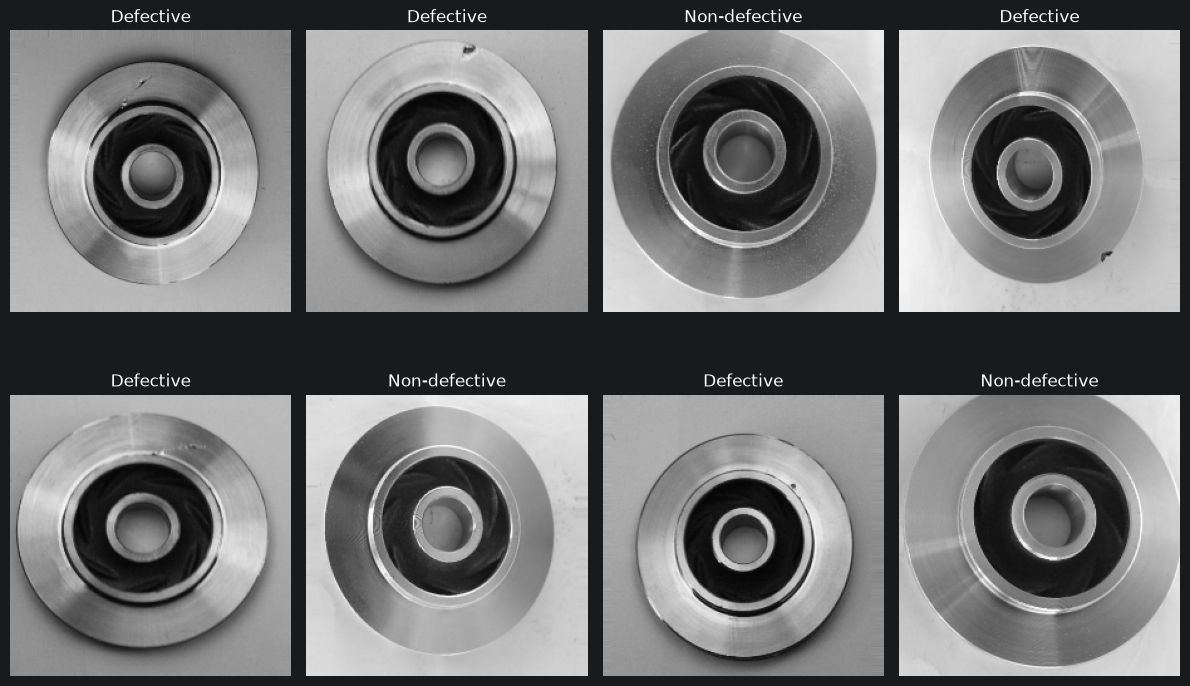

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):

    for i in range(8):

        ax = plt.subplot(2, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        label = int(labels[i].numpy())

        if label == 0:
            title = "Non-defective"
        else:
            title = "Defective"

        plt.title(title)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [15]:
inputs = layers.Input(shape=(224, 224, 3))

x = preprocess_input(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dropout(0.20)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

mobilenet_model = models.Model(
    inputs,
    outputs
)

mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [17]:
mobilenet_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="../models/best_mobilenetv2_proper.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [18]:
mobilenet_history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=mobilenet_callbacks
)

Epoch 1/15


B:\DEEP_LEARNING\casting-quality-inspection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 714ms/step - accuracy: 0.7143 - loss: 0.5465 - precision: 0.7388 - recall: 0.8117 - val_accuracy: 0.8821 - val_loss: 0.3099 - val_precision: 0.9608 - val_recall: 0.8376 - learning_rate: 0.0010
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 659ms/step - accuracy: 0.8549 - loss: 0.3318 - precision: 0.8952 - recall: 0.8592 - val_accuracy: 0.9333 - val_loss: 0.2129 - val_precision: 0.9262 - val_recall: 0.9658 - learning_rate: 0.0010
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 606ms/step - accuracy: 0.8835 - loss: 0.2805 - precision: 0.9016 - recall: 0.9049 - val_accuracy: 0.9179 - val_loss: 0.2039 - val_precision: 0.9040 - val_recall: 0.9658 - learning_rate: 0.0010
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 658ms/step - accuracy: 0.9088 - loss: 0.2259 - precision: 0.9345 - recall: 0.9122 - val_accuracy: 0.9487 - val_loss: 0.1451 - val_precision: 0.9735 - val_recall: 0.9402 - learning_rate: 0.0010
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 627ms/step - accuracy: 0.9132

In [19]:
test_results = mobilenet_model.evaluate(test_dataset)

for name, value in zip(
    mobilenet_model.metrics_names,
    test_results
):
    print(f"{name}: {value:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 692ms/step - accuracy: 0.9692 - loss: 0.1214 - precision: 0.9912 - recall: 0.9573
loss: 0.1214
compile_metrics: 0.9692


In [20]:
mobilenet_probabilities = mobilenet_model.predict(
    test_dataset
).flatten()

mobilenet_predictions = (
    mobilenet_probabilities >= 0.50
).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 829ms/step


In [21]:
mobilenet_actual = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

In [22]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(
    classification_report(
        mobilenet_actual,
        mobilenet_predictions,
        target_names=[
            "Non-defective",
            "Defective"
        ]
    )
)

               precision    recall  f1-score   support

Non-defective       0.94      0.99      0.96        78
    Defective       0.99      0.96      0.97       117

     accuracy                           0.97       195
    macro avg       0.97      0.97      0.97       195
 weighted avg       0.97      0.97      0.97       195



In [23]:
mobilenet_matrix = confusion_matrix(
    mobilenet_actual,
    mobilenet_predictions
)

tn, fp, fn, tp = mobilenet_matrix.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 77
False Positives: 1
False Negatives: 5
True Positives  : 112


In [24]:
print(
    f"Accuracy : {accuracy_score(mobilenet_actual, mobilenet_predictions):.4f}"
)

print(
    f"Precision: {precision_score(mobilenet_actual, mobilenet_predictions):.4f}"
)

print(
    f"Recall   : {recall_score(mobilenet_actual, mobilenet_predictions):.4f}"
)

print(
    f"F1       : {f1_score(mobilenet_actual, mobilenet_predictions):.4f}"
)

Accuracy : 0.9692
Precision: 0.9912
Recall   : 0.9573
F1       : 0.9739


In [25]:
from sklearn.metrics import confusion_matrix

mobilenet_matrix = confusion_matrix(
    mobilenet_actual,
    mobilenet_predictions
)

print(mobilenet_matrix)

[[ 77   1]
 [  5 112]]


In [26]:
tn, fp, fn, tp = mobilenet_matrix.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 77
False Positives: 1
False Negatives: 5
True Positives  : 112


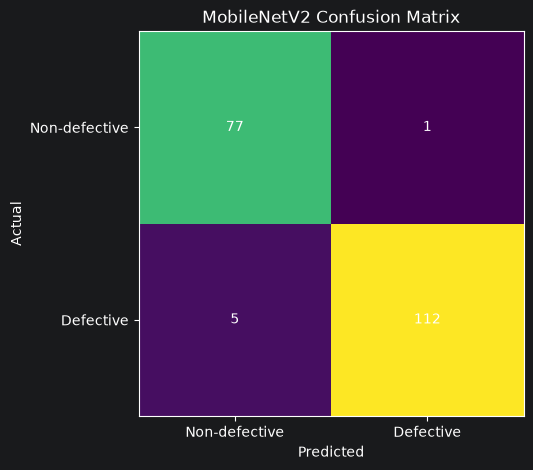

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(mobilenet_matrix)

plt.xticks(
    [0, 1],
    ["Non-defective", "Defective"]
)

plt.yticks(
    [0, 1],
    ["Non-defective", "Defective"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            mobilenet_matrix[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [28]:
val_probabilities = mobilenet_model.predict(
    val_dataset
).flatten()

val_actual = np.concatenate([
    labels.numpy().flatten()
    for images, labels in val_dataset
]).astype(int)

print("Validation samples:", len(val_actual))

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step
Validation samples: 195


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

results = []

for threshold in thresholds:

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        val_actual,
        predictions
    ).ravel()

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            val_actual,
            predictions
        ),
        "precision": precision_score(
            val_actual,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            val_actual,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            val_actual,
            predictions,
            zero_division=0
        ),
        "FP": fp,
        "FN": fn
    })

for result in results:
    print(
        f"Threshold: {result['threshold']:.2f} | "
        f"Accuracy: {result['accuracy']:.4f} | "
        f"Precision: {result['precision']:.4f} | "
        f"Recall: {result['recall']:.4f} | "
        f"F1: {result['f1']:.4f} | "
        f"FP: {result['FP']} | "
        f"FN: {result['FN']}"
    )

Threshold: 0.30 | Accuracy: 0.9795 | Precision: 0.9748 | Recall: 0.9915 | F1: 0.9831 | FP: 3 | FN: 1
Threshold: 0.35 | Accuracy: 0.9846 | Precision: 0.9831 | Recall: 0.9915 | F1: 0.9872 | FP: 2 | FN: 1
Threshold: 0.40 | Accuracy: 0.9897 | Precision: 0.9915 | Recall: 0.9915 | F1: 0.9915 | FP: 1 | FN: 1
Threshold: 0.45 | Accuracy: 0.9897 | Precision: 0.9915 | Recall: 0.9915 | F1: 0.9915 | FP: 1 | FN: 1
Threshold: 0.50 | Accuracy: 0.9897 | Precision: 0.9915 | Recall: 0.9915 | F1: 0.9915 | FP: 1 | FN: 1
Threshold: 0.55 | Accuracy: 0.9897 | Precision: 1.0000 | Recall: 0.9829 | F1: 0.9914 | FP: 0 | FN: 2
Threshold: 0.60 | Accuracy: 0.9897 | Precision: 1.0000 | Recall: 0.9829 | F1: 0.9914 | FP: 0 | FN: 2
Threshold: 0.65 | Accuracy: 0.9897 | Precision: 1.0000 | Recall: 0.9829 | F1: 0.9914 | FP: 0 | FN: 2
Threshold: 0.70 | Accuracy: 0.9897 | Precision: 1.0000 | Recall: 0.9829 | F1: 0.9914 | FP: 0 | FN: 2


In [32]:
eligible = [
    r for r in results
    if r["recall"] >= 0.95
]

best_result = max(
    eligible,
    key=lambda r: r["f1"]
)

print("Selected threshold:")
print(best_result)

Selected threshold:
{'threshold': 0.4, 'accuracy': 0.9897435897435898, 'precision': 0.9914529914529915, 'recall': 0.9914529914529915, 'f1': 0.9914529914529915, 'FP': np.int64(1), 'FN': np.int64(1)}


In [33]:
selected_threshold = best_result["threshold"]

test_predictions_tuned = (
    mobilenet_probabilities >= selected_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    mobilenet_actual,
    test_predictions_tuned
).ravel()

print("Selected threshold:", selected_threshold)
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

print(
    f"Accuracy : {accuracy_score(mobilenet_actual, test_predictions_tuned):.4f}"
)

print(
    f"Precision: {precision_score(mobilenet_actual, test_predictions_tuned):.4f}"
)

print(
    f"Recall   : {recall_score(mobilenet_actual, test_predictions_tuned):.4f}"
)

print(
    f"F1       : {f1_score(mobilenet_actual, test_predictions_tuned):.4f}"
)

Selected threshold: 0.4
True Negatives : 77
False Positives: 1
False Negatives: 5
True Positives  : 112
Accuracy : 0.9692
Precision: 0.9912
Recall   : 0.9573
F1       : 0.9739


In [34]:
# First keep the entire model frozen
base_model.trainable = True

# Freeze the early layers
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Total layers:", len(base_model.layers))
print(
    "Trainable layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total layers: 154
Trainable layers: 36


In [35]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [36]:
fine_tune_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.0000001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="../models/best_mobilenetv2_finetuned.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [37]:
fine_tune_history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=fine_tune_callbacks
)

Epoch 1/10


B:\DEEP_LEARNING\casting-quality-inspection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 845ms/step - accuracy: 0.9703 - loss: 0.0992 - precision: 0.9815 - recall: 0.9689 - val_accuracy: 0.9897 - val_loss: 0.0570 - val_precision: 1.0000 - val_recall: 0.9829 - learning_rate: 1.0000e-05
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 780ms/step - accuracy: 0.9736 - loss: 0.0667 - precision: 0.9852 - recall: 0.9707 - val_accuracy: 0.9795 - val_loss: 0.0619 - val_precision: 0.9748 - val_recall: 0.9915 - learning_rate: 1.0000e-05
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 772ms/step - accuracy: 0.9824 - loss: 0.0545 - precision: 0.9854 - recall: 0.9854 - val_accuracy: 0.9641 - val_loss: 0.0985 - val_precision: 0.9508 - val_recall: 0.9915 - learning_rate: 1.0000e-05
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 807ms/step - accuracy: 0.9802 - loss: 0.0520 - precision: 0.9835 - recall: 0.9835 - val_accuracy: 0.9949 - val_loss: 0.0409 - val_precision: 1.0000 - val_recall: 0.9915 - learning_rate: 5.0000e-06
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 787ms/step - 

In [38]:
fine_tune_results = mobilenet_model.evaluate(
    test_dataset
)

for name, value in zip(
    mobilenet_model.metrics_names,
    fine_tune_results
):
    print(f"{name}: {value:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 343ms/step - accuracy: 0.9744 - loss: 0.0681 - precision: 1.0000 - recall: 0.9573
loss: 0.0681
compile_metrics: 0.9744


In [39]:
fine_tune_probabilities = mobilenet_model.predict(
    test_dataset
).flatten()

fine_tune_predictions = (
    fine_tune_probabilities >= 0.50
).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step  


In [40]:
fine_tune_actual = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print(
    f"Accuracy : {accuracy_score(fine_tune_actual, fine_tune_predictions):.4f}"
)

print(
    f"Precision: {precision_score(fine_tune_actual, fine_tune_predictions):.4f}"
)

print(
    f"Recall   : {recall_score(fine_tune_actual, fine_tune_predictions):.4f}"
)

print(
    f"F1       : {f1_score(fine_tune_actual, fine_tune_predictions):.4f}"
)

tn, fp, fn, tp = confusion_matrix(
    fine_tune_actual,
    fine_tune_predictions
).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Accuracy : 0.9744
Precision: 1.0000
Recall   : 0.9573
F1       : 0.9782
TN: 78
FP: 0
FN: 5
TP: 112


In [42]:
mobilenet_model.save(
    "../models/final_mobilenetv2_finetuned.keras"
)

print("Final model saved.")

Final model saved.
